![](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)

# Clase 01: ANNs desde cero

profesor [Carlos Daniel Jiménez](danieljimenez88m@gmail.com)


## Que vas a ver en esta notebook

- por que un modelo lineal no alcanza para problemas no lineales,
- como una MLP aprende una frontera mas flexible,
- por que las activaciones importan,
- como leer backpropagation sin tratarlo como magia.

La idea central es simple: una red neuronal no aparece para complicar un problema, sino para aprender representaciones intermedias cuando una sola recta o plano no alcanzan.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


from tools.notebook_utils import choose_value, configure_runtime, plot_history

runtime = configure_runtime(seed=7)
print(runtime.summary())
        


seed=7 | smoke=False | online_mode=False | device=mps


## Por que existen las redes neuronales

Un perceptron o una regresion logistica aplican una combinacion lineal sobre las entradas. Eso funciona bien cuando el problema es separable por una frontera simple, pero falla cuando la geometria de los datos es curva, fragmentada o jerarquica.

Una MLP resuelve ese limite agregando dos ideas:

1. capas ocultas que construyen transformaciones intermedias,
2. activaciones no lineales que evitan que toda la red colapse en una sola recta.

En 2026 seguimos ensenando esta base porque todas las arquitecturas posteriores heredan la misma logica: representaciones utiles, funcion de perdida y optimizacion por gradiente.


ReLU: derivada 0 o 1 -> no satura en x>0, barata y estable
GELU: usada en GPT, BERT, T5 -> suave y sin zona muerta completa


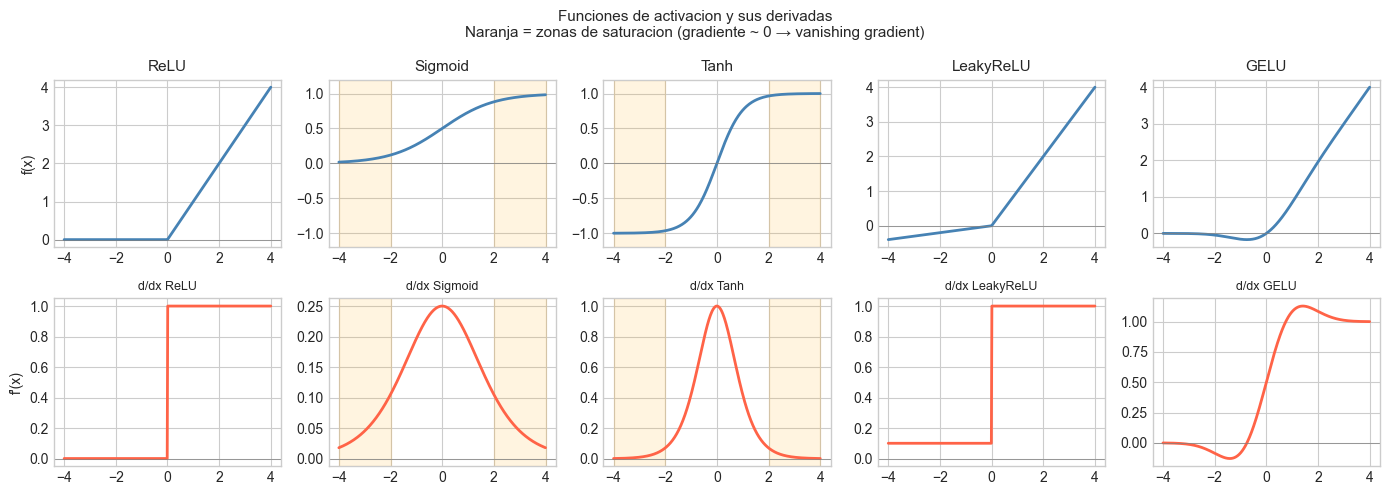

In [2]:
# Visualizacion de funciones de activacion y sus derivadas
import torch
import matplotlib.pyplot as plt
import numpy as np

x_vals = torch.linspace(-4, 4, 400)
x_vals.requires_grad_(True)

def compute_activation_and_grad(fn):
    x = x_vals.detach().clone().requires_grad_(True)
    y = fn(x)
    y.sum().backward()
    return y.detach().numpy(), x.grad.detach().numpy()

activations = {
    'ReLU':      torch.nn.functional.relu,
    'Sigmoid':   torch.sigmoid,
    'Tanh':      torch.tanh,
    'LeakyReLU': lambda x: torch.nn.functional.leaky_relu(x, negative_slope=0.1),
    'GELU':      torch.nn.functional.gelu,
}

fig, axes = plt.subplots(2, len(activations), figsize=(14, 5))
x_np = x_vals.detach().numpy()

for col_idx, (name, fn) in enumerate(activations.items()):
    y_vals, dy_vals = compute_activation_and_grad(fn)
    axes[0, col_idx].plot(x_np, y_vals, color='steelblue', lw=2)
    axes[0, col_idx].set_title(name, fontsize=11)
    axes[0, col_idx].axhline(0, color='gray', lw=0.5)
    axes[0, col_idx].set_ylim(-1.2, 1.2) if name in ('Sigmoid', 'Tanh') else None
    axes[1, col_idx].plot(x_np, dy_vals, color='tomato', lw=2)
    axes[1, col_idx].set_title(f'd/dx {name}', fontsize=9)
    axes[1, col_idx].axhline(0, color='gray', lw=0.5)
    # Marcar zonas de saturacion en Sigmoid y Tanh
    if name in ('Sigmoid', 'Tanh'):
        for ax in (axes[0, col_idx], axes[1, col_idx]):
            ax.axvspan(-4, -2, alpha=0.12, color='orange', label='saturacion')
            ax.axvspan(2, 4, alpha=0.12, color='orange')

axes[0, 0].set_ylabel('f(x)')
axes[1, 0].set_ylabel("f'(x)")
fig.suptitle(
    'Funciones de activacion y sus derivadas\n'
    'Naranja = zonas de saturacion (gradiente ~ 0 → vanishing gradient)',
    fontsize=11
)
plt.tight_layout()
# ReLU domina en feedforward por derivada constante (0 o 1) fuera de x<0
# GELU es la activacion preferida en Transformers: suave, no muere, bien calibrada
print('ReLU: derivada 0 o 1 -> no satura en x>0, barata y estable')
print('GELU: usada en GPT, BERT, T5 -> suave y sin zona muerta completa')


{'baseline_val_acc': 0.843, 'baseline_test_acc': 0.867}


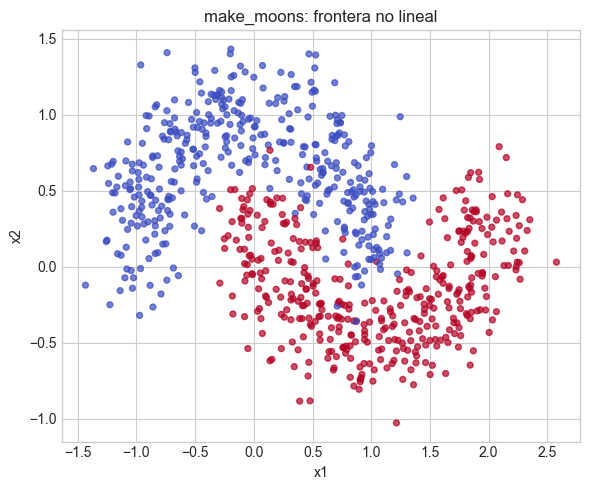

In [4]:
X, y = make_moons(n_samples=int(choose_value(1200, 400)), noise=0.22, random_state=7)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.35, random_state=7, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=7, stratify=y_temp)

baseline = LogisticRegression(max_iter=2000)
baseline.fit(X_train, y_train)

baseline_val = accuracy_score(y_val, baseline.predict(X_val))
baseline_test = accuracy_score(y_test, baseline.predict(X_test))
print({'baseline_val_acc': round(baseline_val, 3), 'baseline_test_acc': round(baseline_test, 3)})

plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', s=18, alpha=0.7)
plt.title('make_moons: frontera no lineal')
plt.xlabel('x1')
plt.ylabel('x2')
plt.tight_layout()
        


## Backpropagation en lenguaje simple

Backpropagation no es una capa ni un truco misterioso. Es el procedimiento eficiente que reparte la responsabilidad del error hacia atras usando la regla de la cadena.

La secuencia practica es:

- la red produce una salida,
- la `loss` mide que tan lejos esta del objetivo,
- el gradiente indica como deberia cambiar cada parametro,
- el optimizador actualiza los pesos.

Si la activacion fuera lineal en todas las capas, apilar capas serviria de poco. Por eso `ReLU` sigue siendo una eleccion fuerte para redes feedforward: barata, simple y estable cuando se combina con una buena inicializacion.


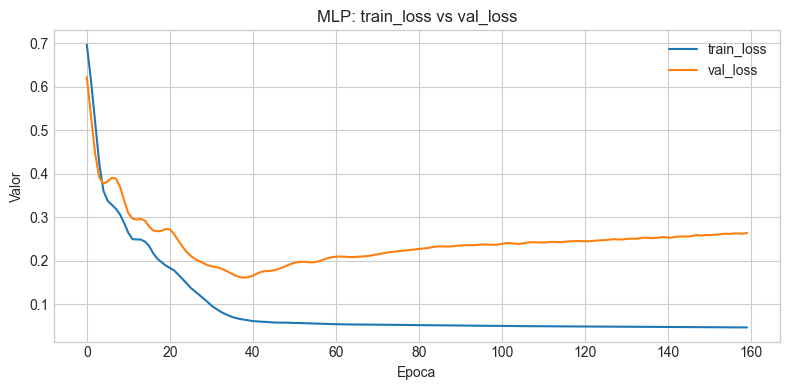

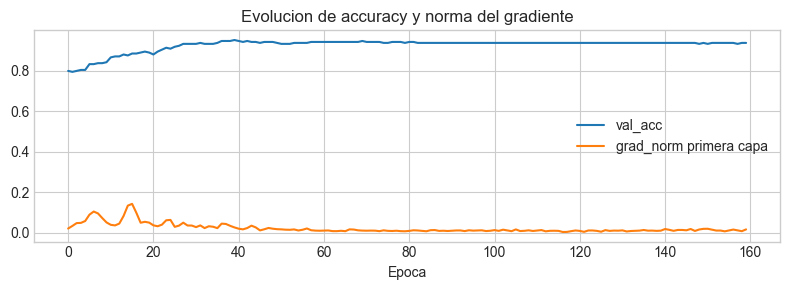

In [13]:
X_train_t = torch.tensor(X_train, dtype=torch.float32, device=runtime.device)
y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32, device=runtime.device)
X_val_t = torch.tensor(X_val, dtype=torch.float32, device=runtime.device)
y_val_t = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32, device=runtime.device)
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=runtime.device)

class MoonMLP(torch.nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(2, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 1),
        )

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.net(features)

model = MoonMLP().to(runtime.device)
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.03, weight_decay=1e-3)
epochs = int(choose_value(160, 40))
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
grad_norms = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_t)
    loss = loss_fn(logits, y_train_t)
    loss.backward()
    grad_norm = model.net[0].weight.grad.norm().item()
    grad_norms.append(grad_norm)
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        val_logits = model(X_val_t)
        val_loss = loss_fn(val_logits, y_val_t)
        val_pred = (torch.sigmoid(val_logits) >= 0.5).int().cpu().numpy().ravel()
        val_acc = accuracy_score(y_val, val_pred)

    history['train_loss'].append(float(loss.item()))
    history['val_loss'].append(float(val_loss.item()))
    history['val_acc'].append(float(val_acc))

plot_history(history, metrics=('train_loss', 'val_loss'), title='MLP: train_loss vs val_loss')
plt.figure(figsize=(8, 3))
plt.plot(history['val_acc'], label='val_acc')
plt.plot(grad_norms, label='grad_norm primera capa')
plt.title('Evolucion de accuracy y norma del gradiente')
plt.xlabel('Epoca')
plt.legend()
plt.tight_layout()
        


{'logistic_regression_test_acc': 0.867, 'mlp_test_acc': 0.967}


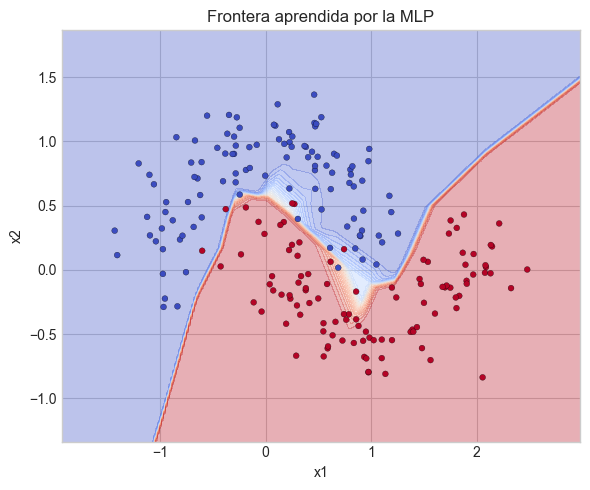

In [12]:
@torch.inference_mode()
def plot_decision_boundary(model: torch.nn.Module, X: np.ndarray, y: np.ndarray) -> None:
    grid_x, grid_y = np.meshgrid(
        np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 250),
        np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 250),
    )
    grid = np.c_[grid_x.ravel(), grid_y.ravel()]
    grid_t = torch.tensor(grid, dtype=torch.float32, device=runtime.device)
    probs = torch.sigmoid(model(grid_t)).cpu().numpy().reshape(grid_x.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(grid_x, grid_y, probs, levels=30, cmap='coolwarm', alpha=0.35)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=18, edgecolor='k', linewidth=0.2)
    plt.title('Frontera aprendida por la MLP')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.tight_layout()

model.eval()
with torch.inference_mode():
    mlp_test_pred = (torch.sigmoid(model(X_test_t)) >= 0.5).int().cpu().numpy().ravel()
mlp_test_acc = accuracy_score(y_test, mlp_test_pred)

print({'logistic_regression_test_acc': round(baseline_test, 3), 'mlp_test_acc': round(mlp_test_acc, 3)})
plot_decision_boundary(model, X_test, y_test)
        


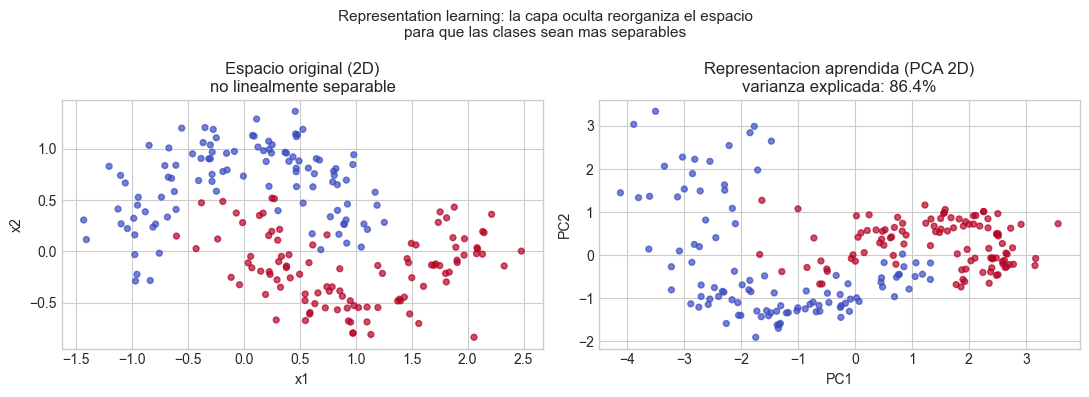

In [14]:
# Representaciones intermedias: como la MLP transforma el espacio de entrada
from sklearn.decomposition import PCA

model.eval()
# Extraer activaciones de la primera capa oculta (32 neuronas)
activations_hidden = []

def hook_fn(module, input, output):
    activations_hidden.append(output.detach().cpu())

hook = model.net[1].register_forward_hook(hook_fn)  # ReLU despues de primera Linear
with torch.inference_mode():
    _ = model(X_test_t)
hook.remove()

hidden_repr = activations_hidden[0].numpy()  # (n_test, 32)

# Proyeccion PCA de 32D -> 2D
pca = PCA(n_components=2, random_state=7)
repr_2d = pca.fit_transform(hidden_repr)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Espacio original
axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', s=18, alpha=0.7)
axes[0].set_title('Espacio original (2D)\nno linealmente separable')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')

# Representacion aprendida
axes[1].scatter(repr_2d[:, 0], repr_2d[:, 1], c=y_test, cmap='coolwarm', s=18, alpha=0.7)
axes[1].set_title(f'Representacion aprendida (PCA 2D)\n'
                  f'varianza explicada: {pca.explained_variance_ratio_.sum():.1%}')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.suptitle(
    'Representation learning: la capa oculta reorganiza el espacio\n'
    'para que las clases sean mas separables',
    fontsize=11
)
plt.tight_layout()
# Esto concretiza por que llamamos a esto "representation learning":
# la red no memoriza los puntos, aprende una transformacion que facilita la clasificacion


## Para cerrar

### Preguntas practicas

- En que parte exacta la MLP gana flexibilidad frente al baseline lineal.
- Que senal del entrenamiento sugiere que el modelo realmente esta aprendiendo.
- Que pasa si cambias `ReLU` por `tanh` o si haces la red mucho mas profunda.

### Errores comunes

- creer que mas capas siempre implican mejor generalizacion,
- olvidar mirar la validacion y solo celebrar el train loss,
- pensar que backpropagation y descenso por gradiente son la misma cosa.
